# データセットの概要
JEPXは翌日の任意の30分間における1kWhの値段を表した時系列データで、未来の需給の期待値となっている。

例えば、3月31日の10:00-10:30の価格は3月30日の午後までに入札がされて決定される

正確な定義
>JEPX価格とは、
前日に行われた入札に基づいて決定される、
翌日の各30分時間帯における
電力1kWhあたりの市場クリアリング価格である。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = (
    REPO_ROOT
    / "A_Hawkes_Model_Approach_to_Modeling_Price_Spikes_in_the_Japanese_Electricity_Market"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("scipy:", scipy.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4
scipy: 1.17.1


In [ ]:
# read csv
from pathlib import Path

csv_path = RAW_DATA_DIR / "electricity/spot_summary_2016.csv"
df = pd.read_csv(csv_path, encoding="cp932")
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
0,2016/04/01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN
1,2016/04/01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN
2,2016/04/01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN
3,2016/04/01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN
4,2016/04/01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN


In [ ]:
# 日付をdatetime化
df["受渡日"] = pd.to_datetime(df["受渡日"])

# 時刻コード → 30分刻み
df["datetime"] = df["受渡日"] + pd.to_timedelta((df["時刻コード"] - 1) * 30, unit="min")

# indexに設定
df = df.set_index("datetime").sort_index()
df.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,,,
2016-04-01 00:00:00,2016-04-01,1,5077000,2120500,675500,6.61,8.66,6.69,6.69,6.69,6.69,6.69,6.69,6.69,4.00,1665000,45000,NaN,NaN
2016-04-01 00:30:00,2016-04-01,2,5621500,2239000,755500,6.34,8.66,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,1979000,195000,NaN,NaN
2016-04-01 01:00:00,2016-04-01,3,5710500,2219000,713500,6.34,7.20,6.34,6.34,6.34,6.34,6.34,6.34,6.34,4.00,2236500,195000,NaN,NaN
2016-04-01 01:30:00,2016-04-01,4,5536000,2202500,717500,6.25,7.10,6.03,6.03,6.03,6.03,6.03,6.03,6.03,4.00,2236500,195000,NaN,NaN
2016-04-01 02:00:00,2016-04-01,5,5461000,2192000,870500,6.57,7.10,6.57,6.57,6.57,6.57,6.57,6.57,6.57,5.28,2191500,170000,NaN,NaN


In [4]:
df["エリアプライス東京(円/kWh)"].dtype

dtype('float64')

In [5]:
# 欠損チェック
# is_monotonic_increasing　数列が単調増加になっているか判定（インデックスが昇順であることを確認）
print(df.index.is_monotonic_increasing)

# 周期確認
print(pd.infer_freq(df.index))

True
30min


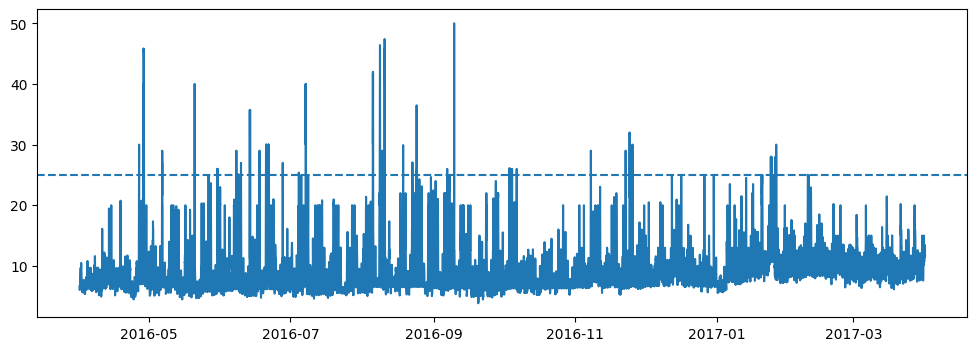

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

In [ ]:
import pandas as pd

# エリアプライス列だけ抽出
area_cols = [col for col in df.columns if "エリアプライス" in col]

# 統計量計算
stats = pd.DataFrame({
    "mean": df[area_cols].mean(),
    "median": df[area_cols].median(),
    "std": df[area_cols].std(),
    "skew": df[area_cols].skew(),
    "95": df[area_cols].quantile(
        0.95
    ),  # 歪度　スパイクが起きているのでsknw>0になる可能性が
})

stats

,mean,median,std,skew,95
エリアプライス北海道(円/kWh),11.940906,10.30,5.501458,2.126274,22.0000
エリアプライス東北(円/kWh),9.314014,8.16,4.136732,2.878465,17.0100
エリアプライス東京(円/kWh),9.320792,8.16,4.134377,2.881132,17.0100
エリアプライス中部(円/kWh),8.291881,7.52,3.012030,1.413734,13.9505
エリアプライス北陸(円/kWh),8.282693,7.52,3.023858,1.387834,13.9505
エリアプライス関西(円/kWh),8.291102,7.52,3.012470,1.413240,13.9505
エリアプライス中国(円/kWh),8.290057,7.52,3.012791,1.413650,13.9505
エリアプライス四国(円/kWh),8.290124,7.52,3.012777,1.413608,13.9505
エリアプライス九州(円/kWh),8.207001,7.39,3.051229,1.395070,13.9505


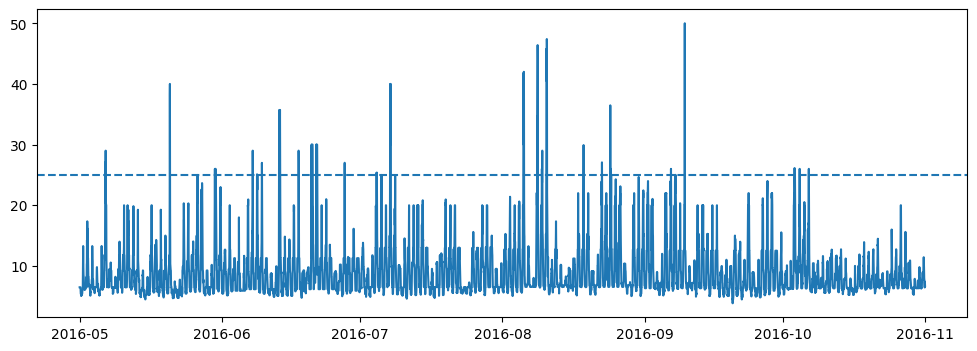

In [ ]:
plt.figure(figsize=(12, 4))
df_aug_oct = df.loc["2016-05-01":"2016-10-31"]
plt.plot(df_aug_oct["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

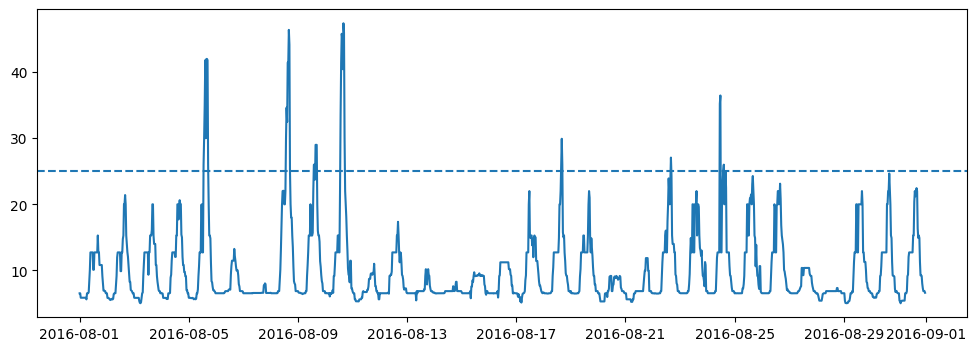

In [ ]:
plt.figure(figsize=(12, 4))
df_aug = df.loc["2016-08-01":"2016-08-31"]
plt.plot(df_aug["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

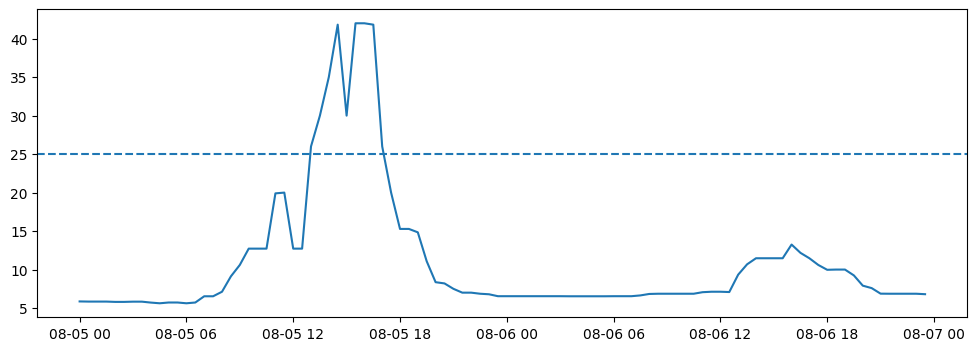

In [ ]:
plt.figure(figsize=(12, 4))
df_aug_day_1 = df.loc["2016-08-05":"2016-08-06"]
plt.plot(df_aug_day_1["エリアプライス東京(円/kWh)"])
plt.axhline(y=25, linestyle="--")
plt.show()

<class 'pandas.core.series.Series'>


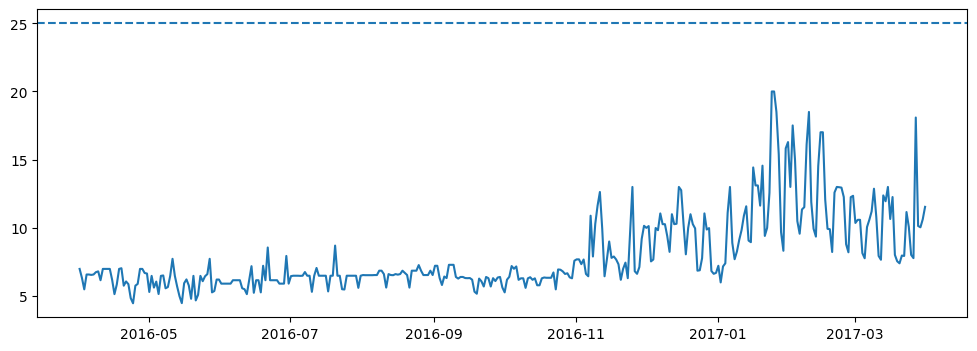

In [ ]:
# 07:00-07:30＋東京の取引だけ抽出
plt.figure(figsize=(12, 4))
df_tokyo_start = df[df["時刻コード"] == 15]["エリアプライス東京(円/kWh)"]
plt.axhline(y=25, linestyle="--")
print(type(df_tokyo_start))
plt.plot(df_tokyo_start)

<class 'pandas.core.series.Series'>


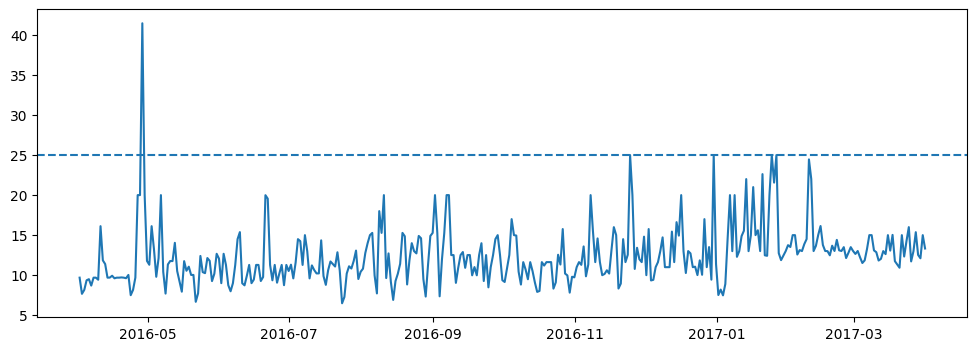

In [12]:
# 18:00-18:30＋東京の取引だけ抽出
plt.figure(figsize=(12, 4))
df_tokyo_start = df[df["時刻コード"] == 37]["エリアプライス東京(円/kWh)"]
plt.axhline(y=25, linestyle="--")
print(type(df_tokyo_start))
plt.plot(df_tokyo_start)